# Advanced K-Means Algorithms

In this notebook, we implement two advanced modifications to the standard K-Means clustering algorithm from scratch:
1. **K-Means++:** A smarter initialization technique that places starting centroids as far apart from each other as mathematically possible.
2. **Breathing K-Means:** A brilliant meta-heuristic that actively "inhales" (adds) centroids to high-error regions and "exhales" (removes) useless centroids to prevent the algorithm from getting stuck in bad groupings.


## 1. K-Means++ Implementation (Smart Start)

Instead of dropping all `K` centroids completely randomly, K-Means++ picks the first one randomly. For every subsequent centroid, it calculates the squared distance ($D^2$) to the nearest existing centroid and uses that as a weighted probability. Points far away have a massive chance of being picked.


K-Means++ realizes that the best way to prevent bad clusters is to guarantee that the starting centroids are spaced as far away from each other as mathematically possible.

How it works under the hood (The $D^2$ Probability technique):

1. Centroid 1: It picks the very first centroid completely blindly. ($X$ gets chosen).
2. The Measurement Loop: It calculates the physical distance from every single data point to that established centroid. (Let's call this Distance $D$).
3. Squaring the Distance: It squares every single distance ($D^2$). Making it squared means points that are far away instantly look significantly farther away, and points that are close get diminished.
4. The Probability Lottery: It converts those $D^2$ values into percentages. Imagine you have a lottery wheel:
A point that is very far away gets 80% of the pie on the wheel.
A point right next to the original centroid gets 0.001% of the pie.
5. Centroid 2: The algorithm spins the wheel and picks a new point. Because of the massive $D^2$ weighting, it is practically guaranteed to pick a point on the complete opposite side of the dataset.
6. Repeat: It does this over and over until it has exactly k centroids, and then it just proceeds using the normal standard K-Means loop!

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

class MyKMeansPlusPlus:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels_ = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        np.random.seed(42)
        
        # --- K-Means++ Initialization ---
        self.centroids = np.empty((self.k, n_features))
        
        # Pick first centroid randomly
        first_idx = np.random.choice(n_samples)
        self.centroids[0] = X[first_idx]
        
        # Pick remaining centroids based on D^2 probability
        for i in range(1, self.k):
            dist_sq = np.zeros(n_samples)
            for j in range(n_samples):
                distances = [np.linalg.norm(X[j] - c)**2 for c in self.centroids[:i]]
                dist_sq[j] = np.min(distances)
            
            probs = dist_sq / np.sum(dist_sq)
            next_idx = np.random.choice(n_samples, p=probs)
            self.centroids[i] = X[next_idx]
            
        # --- Standard K-Means Loop ---
        for i in range(self.max_iters):
            clusters = [[] for _ in range(self.k)]
            
            for point_idx, point in enumerate(X):
                distances = [np.linalg.norm(point - centroid) for centroid in self.centroids]
                clusters[np.argmin(distances)].append(point_idx)
                
            prev_centroids = np.copy(self.centroids)
            for cluster_idx, point_indices in enumerate(clusters):
                if len(point_indices) == 0: continue
                self.centroids[cluster_idx] = np.mean(X[point_indices], axis=0)
                
            if np.sum(np.linalg.norm(self.centroids - prev_centroids, axis=1)) < self.tol:
                break
                
        self.labels_ = np.zeros(n_samples, dtype=int)
        for cluster_idx, point_indices in enumerate(clusters):
            for point_idx in point_indices:
                self.labels_[point_idx] = cluster_idx


## 2. Breathing K-Means Implementation (Self-Correcting)

This algorithm cycles through "breathing in" by adding new centroids next to clusters with massive internal errors, and "breathing out" by deleting centroids with low utility (e.g., clusters with barely any points).


Breathing K-Means realizes that no matter how smart your start is, mistakes still happen mid-run. Local Minima (bad clusters) can still form. Breathing K-Means fixes this by dynamically injecting life into bad areas and suffocating useless areas.

It literally mimics a lung breathing:

A. Inhale (Adding new workers to struggling areas):

1. The algorithm pauses and measures the "Error" (Sum of Squared Errors) for every single cluster. This is just a measurement of how tightly packed they are.
2. If it finds a specific cluster where the points are scattered ridiculously far away from the centroid, it knows that single centroid is struggling and needs help.
3. The algorithm Inhales: It forcefully creates $m$ brand new "assist" centroids (e.g., $m=1$), and drops them exactly into those highly scattered clusters. Temporary mathematically optimal chaos ensues as now you have too many total centroids ($k + m$).

B. Exhale (Firing useless workers):

1. After letting the new ($k + m$) centroids settle into a rhythm, the algorithm pauses and checks the "Utility" of every centroid.
2. If two centroids ended up competing over the exact same small group of points, or if a centroid is practically empty, that centroid is deemed mathematically useless.
3. The algorithm Exhales: It perfectly deletes the $m$ most useless centroids in the entire system, naturally restoring the balance backward to exactly $k$ centroids.

By constantly cycling this Inhale/Exhale process, the model structurally manipulates the system to escape terrible groupings and perfectly home in on the optimal final position!



In [2]:
class MyBreathingKMeans:
    def __init__(self, k=3, m=1, cycles=3, inner_iters=20, tol=1e-4):
        self.k = k
        self.m = m # Extra centroids to breathe in/out
        self.cycles = cycles
        self.inner_iters = inner_iters
        self.tol = tol
        self.centroids = None
        self.labels_ = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        np.random.seed(42)
        
        # Random start & let it settle
        self.centroids = X[np.random.choice(n_samples, self.k, replace=False)]
        self._run_kmeans(X, self.inner_iters)
        
        # Breathing Cycles
        for cycle in range(self.cycles):
            # --- BREATHE IN (Add m centroids) ---
            cluster_sse = np.zeros(self.centroids.shape[0])
            for idx, pt in enumerate(X):
                cluster_id = self.labels_[idx]
                cluster_sse[cluster_id] += np.linalg.norm(pt - self.centroids[cluster_id])**2
                
            worst_clusters = np.argsort(cluster_sse)[-self.m:]
            new_centroids = [self.centroids[wc] + np.random.normal(0, 0.5, size=n_features) for wc in worst_clusters]
            self.centroids = np.vstack([self.centroids, new_centroids])
            
            # Settle with K+m centroids
            self._run_kmeans(X, self.inner_iters)
            
            # --- BREATHE OUT (Remove m centroids) ---
            cluster_counts = np.bincount(self.labels_, minlength=self.centroids.shape[0])
            weakest_clusters = np.argsort(cluster_counts)[:self.m]
            self.centroids = np.delete(self.centroids, weakest_clusters, axis=0)
            
            # Settle back to K centroids
            self._run_kmeans(X, self.inner_iters)

    def _run_kmeans(self, X, iterations):
        n_samples = X.shape[0]
        for i in range(iterations):
            clusters = [[] for _ in range(self.centroids.shape[0])]
            
            for point_idx, point in enumerate(X):
                distances = [np.linalg.norm(point - centroid) for centroid in self.centroids]
                clusters[np.argmin(distances)].append(point_idx)
                
            prev_centroids = np.copy(self.centroids)
            for cluster_idx, point_indices in enumerate(clusters):
                if len(point_indices) == 0: continue
                self.centroids[cluster_idx] = np.mean(X[point_indices], axis=0)
                
            if np.sum(np.linalg.norm(self.centroids - prev_centroids, axis=1)) < self.tol:
                break
                
        self.labels_ = np.zeros(n_samples, dtype=int)
        for cluster_idx, point_indices in enumerate(clusters):
            for point_idx in point_indices:
                self.labels_[point_idx] = cluster_idx


## 3. Visualizing Results

Lets generate some synthetic blobs and visually confirm that both of our advanced K-Means algorithms successfully grouped the patterns!


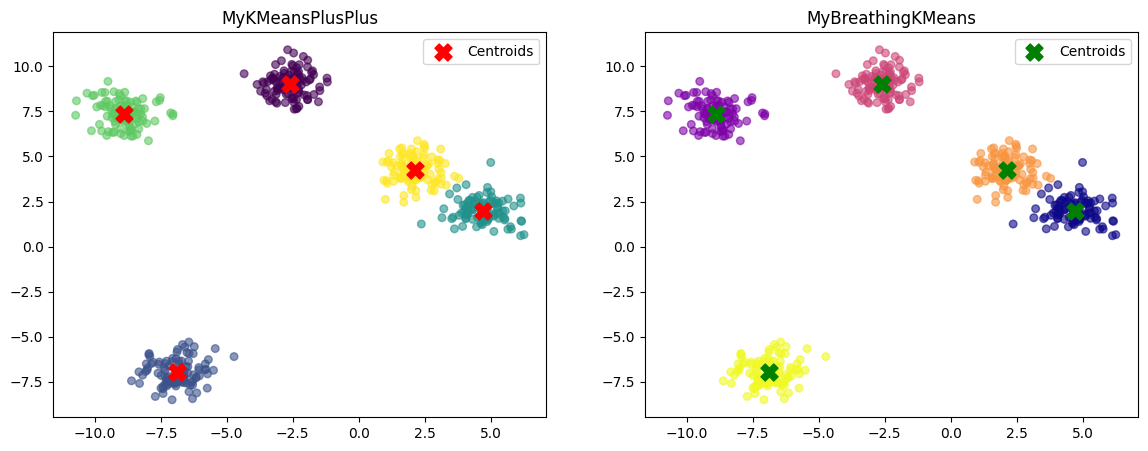

In [3]:
import matplotlib.pyplot as plt

# Generate 5 distinct blobs
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=0.7, random_state=42)

# Train algorithms
km_plus = MyKMeansPlusPlus(k=5, max_iters=100)
km_plus.fit(X)

bkm = MyBreathingKMeans(k=5, m=1, cycles=3)
bkm.fit(X)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot K-Means++
ax1.scatter(X[:, 0], X[:, 1], c=km_plus.labels_, cmap='viridis', s=30, alpha=0.6)
ax1.scatter(km_plus.centroids[:, 0], km_plus.centroids[:, 1], c='red', marker='X', s=150, label='Centroids')
ax1.set_title("MyKMeansPlusPlus")
ax1.legend()

# Plot Breathing K-Means
ax2.scatter(X[:, 0], X[:, 1], c=bkm.labels_, cmap='plasma', s=30, alpha=0.6)
ax2.scatter(bkm.centroids[:, 0], bkm.centroids[:, 1], c='green', marker='X', s=150, label='Centroids')
ax2.set_title("MyBreathingKMeans")
ax2.legend()

plt.show()
